# Dunnhumby Retail Analytics

## 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the process of understanding the
structure, distributions, relationships, and patterns within the data.

The goal of this notebook is to move beyond data quality checks and
identify meaningful business patterns.

We will investigate:

- Sales and transaction behavior
- Customer purchasing behavior
- Basket characteristics
- Product performance
- Store activity
- Discount and promotion behavior
- Time-based purchasing patterns

The findings from this analysis will guide the feature engineering,
customer segmentation, and machine learning stages of the project.

## 2. Load the Raw Datasets

This notebook is designed to run independently.

We will load the raw datasets from the project data directory and use them
for exploratory analysis.

The raw data will not be modified in this notebook.

In [2]:
from pathlib import Path
import pandas as pd

pd.set_option('display.float_format', '{:,.2f}'.format)
# Define the raw data directory
RAW_DIR = Path("../01_data/01_raw/")

# Find all CSV files
csv_files = sorted(RAW_DIR.glob("*.csv"))

# Load all datasets
datasets = {}

for file in csv_files:
  datasets[file.stem] = pd.read_csv(file)

print(f"Loaded {len(datasets)} datasets:")

for name, df in datasets.items():
  print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")



Loaded 8 datasets:
campaign_desc: 30 rows x 4 columns
campaign_table: 7,208 rows x 3 columns
causal_data: 36,786,524 rows x 5 columns
coupon: 124,548 rows x 3 columns
coupon_redempt: 2,318 rows x 4 columns
hh_demographic: 801 rows x 8 columns
product: 92,353 rows x 7 columns
transaction_data: 2,595,732 rows x 12 columns


## 3. Transaction Data

The transaction dataset is the central dataset for the exploratory analysis.

Each row represents a product line within a basket.

A single basket can therefore contain multiple rows.

We will use transaction data to analyze sales, customers, baskets,
products, stores, discounts, and purchasing behavior.

In [28]:
transactions = datasets["transaction_data"]

print(f"Transaction rows: {len(transactions):,}")
print(f"Columns: {transactions.shape[1]}")

Transaction rows: 2,595,732
Columns: 12


## 4. Transaction Overview

Before analyzing individual behaviors, we need to understand the overall
scale of the transaction data.

These metrics provide the basic dimensions of the retail activity represented
in the dataset.

In [29]:
overview = {
  "Households": transactions["household_key"].nunique(),
  "Baskets": transactions["BASKET_ID"].nunique(),
  "Products": transactions["PRODUCT_ID"].nunique(),
  "Stores": transactions["STORE_ID"].nunique(),
  "Days": transactions["DAY"].nunique(),
  "Weeks": transactions["WEEK_NO"].nunique()
}

overview_df = pd.DataFrame(
  overview.items(),
  columns=["Metric", "Value"]
)

display(overview_df)

,Metric,Value
0,Households,2500
1,Baskets,276484
2,Products,92339
3,Stores,582
4,Days,711
5,Weeks,102


## 5. Sales Analysis

Sales value is one of the main business measures in the dataset.

We will first examine the overall sales distribution before analyzing
customers, products, and baskets in more detail.

The median is included because transaction-level sales can be highly skewed
by very large purchases.

In [30]:
sales_summary = pd.DataFrame({
  "Metric": [
    "Total",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum"
  ],
  "Value": [
    transactions["SALES_VALUE"].sum(),
    transactions["SALES_VALUE"].mean(),
    transactions["SALES_VALUE"].median(),
    transactions["SALES_VALUE"].std(),
    transactions["SALES_VALUE"].min(),
    transactions["SALES_VALUE"].max()
  ]
})

display(sales_summary)
#sales_summary = transactions["SALES_VALUE"].describe()
#sales_summary["median"] = transactions["SALES_VALUE"].median()
#display(sales_summary.to_frame("SALES_VALUE").T)

,Metric,Value
0,Total,"8,057,463.08"
1,Mean,3.10
2,Median,2.00
3,Standard Deviation,4.18
4,Minimum,0.00
5,Maximum,840.00


In [31]:
total_sales = transactions["SALES_VALUE"].sum()

print(f"Total sales: ${total_sales:,}")

Total sales: $8,057,463.08


## 6. Sales Over Time

Analyzing sales over time can reveal trends, fluctuations, and changes
in purchasing activity.

The dataset does not contain actual calendar dates, but it includes
a sequential `DAY` variable and a `WEEK_NO` variable.

We will first analyze sales by day and then aggregate the results by week.

Weekly aggregation will help reduce daily noise and make broader
purchasing patterns easier to identify.

### 6.1 Daily Sales

We will aggregate transaction-level sales by day.

This converts millions of transaction rows into a much smaller
time-series dataset that is easier to analyze and visualize.

In [32]:
daily_sales = (
  transactions
  .groupby("DAY", as_index=False)["SALES_VALUE"]
  .sum()
)

daily_sales.head()

,DAY,SALES_VALUE
0,1,549.31
1,2,458.91
2,3,"1,560.37"
3,4,"1,785.64"
4,5,856.93


In [33]:
print(f"Number of days: {len(daily_sales):,}")

Number of days: 711


### 6.2 Daily Sales Trend

A time-series visualization helps us identify periods of unusually
high or low sales activity.

At this stage, the goal is exploration rather than drawing final
business conclusions.

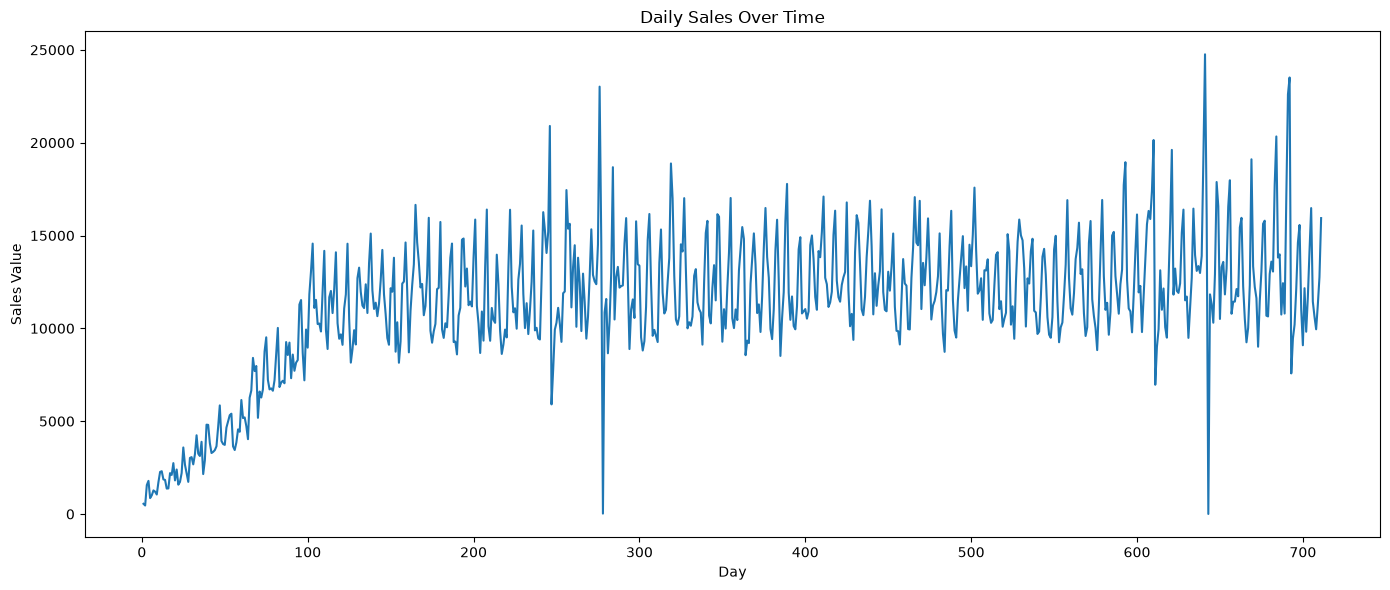

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
  daily_sales["DAY"],
  daily_sales["SALES_VALUE"]
)

plt.xlabel("Day")
plt.ylabel("Sales Value")
plt.title("Daily Sales Over Time")

plt.tight_layout()
plt.show()

## 7. Weekly Sales

Daily sales can contain substantial short-term variation.

Aggregating sales by week provides a smoother view of purchasing activity
and makes longer-term patterns easier to identify.

In [35]:
weekly_sales = (
  transactions
  .groupby("WEEK_NO", as_index=False)["SALES_VALUE"]
  .sum()
)

weekly_sales.head()

,WEEK_NO,SALES_VALUE
0,1,"5,211.16"
1,2,"10,821.35"
2,3,"13,498.20"
3,4,"15,965.99"
4,5,"20,139.82"


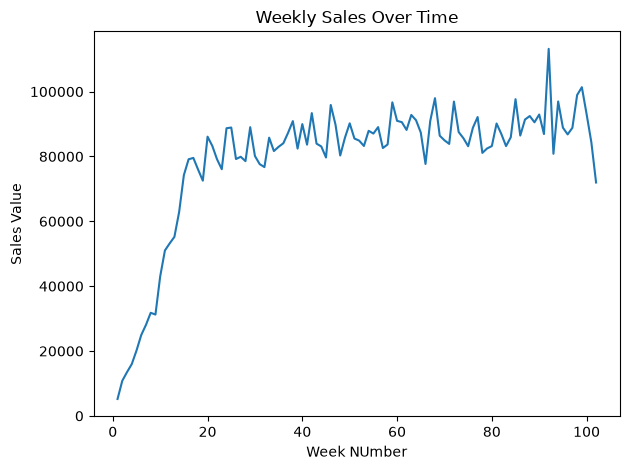

In [36]:
plt.Figure(figsize=(14,6))

plt.plot(
  weekly_sales["WEEK_NO"],
  weekly_sales["SALES_VALUE"]
)

plt.xlabel("Week NUmber")
plt.ylabel("Sales Value")
plt.title("Weekly Sales Over Time")

plt.tight_layout()
plt.show()

## 8. Customer Analysis

Customer-level analysis allows us to understand how households differ
in their purchasing behavior.

We will examine:

- Number of baskets per household
- Total spending per household
- Average basket value
- Average items per basket
- Purchase frequency

These metrics will later become important building blocks for
customer segmentation and feature engineering.

## 9. Baskets per Household

The number of baskets represents how frequently a household made
purchases during the observed period.

This is a simple but important measure of customer engagement.

In [37]:
baskets_per_customer = (
  transactions
  .groupby("household_key")["BASKET_ID"]
  .nunique()
  .reset_index(name="basket_count")
)

display(baskets_per_customer.head(5))

,household_key,basket_count
0,1,86
1,2,45
2,3,47
3,4,30
4,5,40


In [38]:
baskets_per_customer["basket_count"].describe()

count   2,500.00
mean      110.59
std       115.67
min         1.00
25%        39.00
50%        79.00
75%       142.25
max     1,300.00
Name: basket_count, dtype: float64

## 10. Total Spending per Household

Total spending represents the cumulative sales value associated
with each household during the observed period.

This metric can help identify differences in customer value.

In [39]:
spending_per_customer = (
  transactions
  .groupby("household_key")["SALES_VALUE"]
  .sum()
  .reset_index(name="total_spending")
)

display(spending_per_customer)

,household_key,total_spending
0,1,"4,330.16"
1,2,"1,954.34"
2,3,"2,653.21"
3,4,"1,200.11"
4,5,779.06
...,...,...
2495,2496,"4,339.66"
2496,2497,"7,111.98"
2497,2498,"2,601.60"
2498,2499,"3,394.07"


In [40]:
spending_per_customer["total_spending"].describe()

count    2,500.00
mean     3,222.99
std      3,349.03
min          8.17
25%        970.74
50%      2,157.75
75%      4,413.32
max     38,319.79
Name: total_spending, dtype: float64

## 11. Average Basket Value

Average basket value measures how much a household spends per basket.

Because the transaction table contains multiple rows for a single basket,
we first aggregate sales at the basket level and only then calculate
the household average.

In [43]:
basket_sales = (
  transactions
  .groupby(
    ["household_key", "BASKET_ID"]
    ,as_index=False
  )["SALES_VALUE"]
  .sum()
  .rename(columns={"SALES_VALUE": "basket_sales"}))

basket_sales.head()

,household_key,BASKET_ID,basket_sales
0,1,27601281299,78.66
1,1,27774192959,41.10
2,1,28024266849,26.90
3,1,28106322445,63.43
4,1,28235481967,53.45


In [44]:
average_basket_per_customer = (
  basket_sales
  .groupby("household_key")["basket_sales"]
  .mean()
  .reset_index(name="average_basket_value")
)

display(average_basket_per_customer)

,household_key,average_basket_value
0,1,50.35
1,2,43.43
2,3,56.45
3,4,40.00
4,5,19.48
...,...,...
2495,2496,68.88
2496,2497,32.18
2497,2498,15.13
2498,2499,37.71


In [45]:
average_basket_per_customer["average_basket_value"].describe()

count   2,500.00
mean       31.62
std        19.05
min         2.39
25%        18.33
50%        27.42
75%        40.55
max       165.83
Name: average_basket_value, dtype: float64

## 12. Customer Summary

We will combine the customer-level metrics into a single analytical table.

This table will become a foundation for later customer analysis,
feature engineering, and segmentation.

In [46]:
customer_summary = (
  baskets_per_customer
  .merge(
    spending_per_customer,
    on="household_key",
    how="left"
  )
  .merge(
    average_basket_per_customer,
    on="household_key",
    how="left"
  )
)

display(customer_summary.head())

,household_key,basket_count,total_spending,average_basket_value
0,1,86,"4,330.16",50.35
1,2,45,"1,954.34",43.43
2,3,47,"2,653.21",56.45
3,4,30,"1,200.11",40.00
4,5,40,779.06,19.48


In [47]:
customer_summary.shape

(2500, 4)

## 13. Customer Spending Distribution

Customers may differ substantially in their total spending.

Understanding the distribution of customer spending helps us identify
whether spending is relatively balanced across households or concentrated
among a smaller group of customers.

This analysis is descriptive and will later support customer segmentation.

### 13.1 Distribution of Total Spending

A histogram shows how many households fall within different spending
ranges.

This allows us to identify the shape of the customer spending distribution
and detect potential skewness or extreme values.

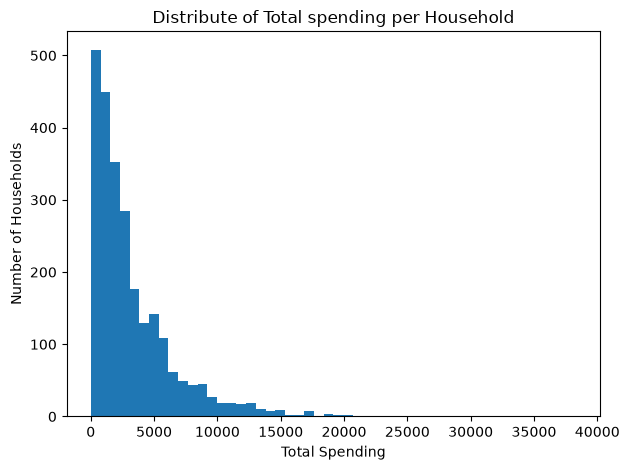

In [48]:
plt.Figure(figsize=(12, 6))

plt.hist(
  customer_summary["total_spending"],
  bins=50
)

plt.xlabel("Total Spending")
plt.ylabel("Number of Households")
plt.title("Distribute of Total spending per Household")

plt.tight_layout()
plt.show()

## 14. Highest-Spending Households

We will inspect the households with the highest total spending.

The purpose is not to label these customers as better customers,
but to understand the range of customer behavior in the dataset.

In [49]:
top_customers = (
  customer_summary
  .sort_values(
    "total_spending",
    ascending=False
  )
  .head(20)
)

display(top_customers)

,household_key,basket_count,total_spending,average_basket_value
1022,1023,603,"38,319.79",63.55
1608,1609,412,"27,859.68",67.62
2321,2322,323,"23,646.92",73.21
1452,1453,761,"21,661.29",28.46
2458,2459,971,"20,671.50",21.29
1429,1430,344,"20,352.99",59.17
717,718,599,"19,299.86",32.22
706,707,498,"19,194.42",38.54
1652,1653,541,"19,153.75",35.40
1110,1111,321,"18,894.72",58.86


## 15. Purchase Frequency vs. Total Spending

We will examine the relationship between the number of baskets
and total household spending.

This can help us understand whether higher purchase frequency
is generally associated with higher total spending.

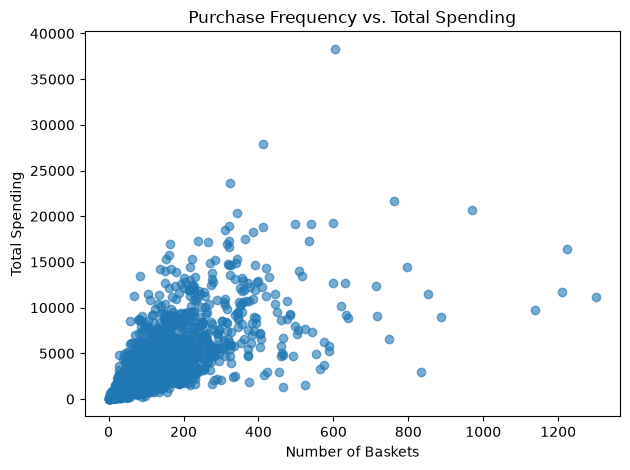

In [52]:
plt.Figure(figsize=(10,6))

plt.scatter(
  customer_summary["basket_count"],
  customer_summary["total_spending"],
  alpha=0.6
)

plt.xlabel("Number of Baskets")
plt.ylabel("Total Spending")
plt.title("Purchase Frequency vs. Total Spending")

plt.tight_layout()
plt.show()

## 16. Correlation Between Purchase Frequency and Spending

We will calculate the correlation between basket frequency and
total spending.

Correlation measures the strength and direction of a linear
relationship between two numerical variables.

In [53]:
correlation = customer_summary[
  ["basket_count", "total_spending"]
].corr()

display(correlation)

,basket_count,total_spending
basket_count,1.00,0.70
total_spending,0.70,1.00


## 17. Average Basket Value Distribution

Total spending alone does not describe customer behavior.

Two households may spend the same total amount while having very
different purchasing patterns.

For example, one household may make many small purchases while
another makes fewer but larger purchases.

We therefore analyze average basket value separately.

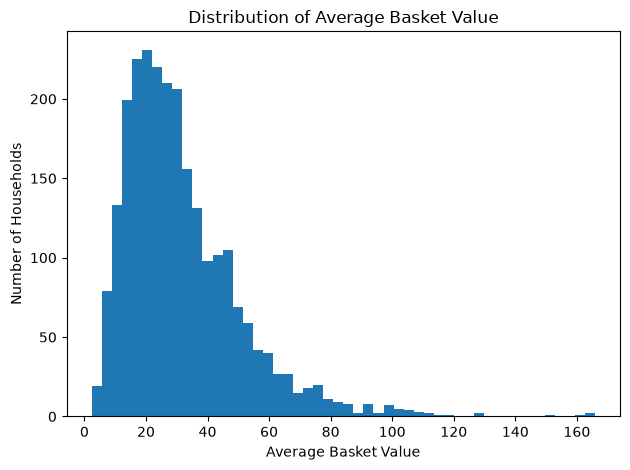

In [54]:
plt.Figure(figsize=(12, 6))

plt.hist(
  customer_summary["average_basket_value"],
  bins=50
)

plt.xlabel("Average Basket Value")
plt.ylabel("Number of Households")
plt.title("Distribution of Average Basket Value")

plt.tight_layout()
plt.show()

## 19. Basket Analysis

A basket represents a single shopping event for a household.

Because the transaction dataset contains one row per product line,
we need to aggregate the transaction data to basket level before
analyzing basket behavior.

We will examine:

- Basket value
- Number of product lines
- Total quantity
- Distribution of basket sizes

## 20. Basket-Level Metrics

We will create a basket-level analytical table.

Each row in this table will represent one unique basket.

This allows us to analyze shopping behavior independently of the
original product-level transaction structure.

In [57]:
basket_summary = (
  transactions
  .groupby(
    ["household_key", "BASKET_ID"],
    as_index=False
  )
  .agg(
    basket_value=("SALES_VALUE", "sum"),
    product_lines=("PRODUCT_ID", "count"),
    total_quantity=("QUANTITY", "sum")
  )
)

display(basket_summary.head())

,household_key,BASKET_ID,basket_value,product_lines,total_quantity
0,1,27601281299,78.66,30,34
1,1,27774192959,41.10,12,14
2,1,28024266849,26.90,12,13
3,1,28106322445,63.43,23,32
4,1,28235481967,53.45,17,20


In [58]:
print(f"Number of baskets: {len(basket_summary):,}")
print(f"Number of columns: {basket_summary.shape[1]}")

Number of baskets: 276,484
Number of columns: 5


## 21. Basket Value

Basket value represents the total sales value associated with
a single shopping event.

We will examine its distribution using descriptive statistics.

In [59]:
basket_summary["basket_value"].describe()

count   276,484.00
mean         29.14
std          36.10
min           0.00
25%           6.96
50%          17.07
75%          36.28
max         961.49
Name: basket_value, dtype: float64

## 22. Basket Value Distribution

The distribution of basket values helps us understand whether
shopping trips tend to have similar values or whether there are
substantial differences between baskets.

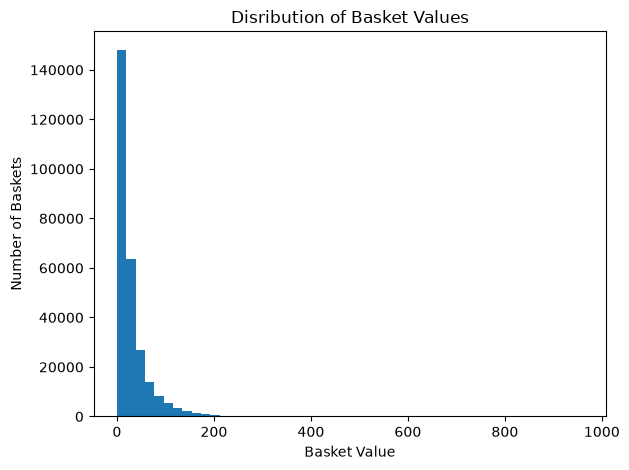

In [ ]:
plt.Figure(figsize=(12, 6))

plt.hist(
  basket_summary["basket_value"],
  bins=50
)

plt.xlabel("Basket Value")
plt.ylabel("Number of Baskets")
plt.title("Distribution of Basket Values")

plt.tight_layout()
plt.show()

## 23. Product Lines per Basket

The number of product lines indicates how many different product
records were included in a basket.

This is not necessarily the number of physical items because a
single product line may contain a quantity greater than one.

In [64]:
basket_summary["product_lines"].describe()

count   276,484.00
mean          9.39
std          12.28
min           1.00
25%           2.00
50%           5.00
75%          12.00
max         168.00
Name: product_lines, dtype: float64

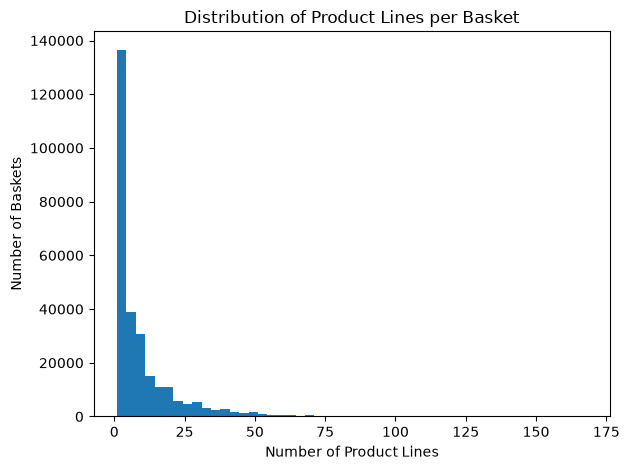

In [65]:
plt.Figure(figsize=(12, 6))

plt.hist(
  basket_summary["product_lines"],
  bins=50
)

plt.xlabel("Number of Product Lines")
plt.ylabel("Number of Baskets")
plt.title("Distribution of Product Lines per Basket")

plt.tight_layout()
plt.show()

## 24. Total Quantity per Basket

Total quantity measures the total number of units represented
by the transaction lines in a basket.

This provides a different perspective from basket value and
product-line count.

In [66]:
basket_summary["total_quantity"].describe()

count   276,484.00
mean        942.86
std       3,420.42
min           0.00
25%           3.00
50%           8.00
75%          22.00
max      89,638.00
Name: total_quantity, dtype: float64

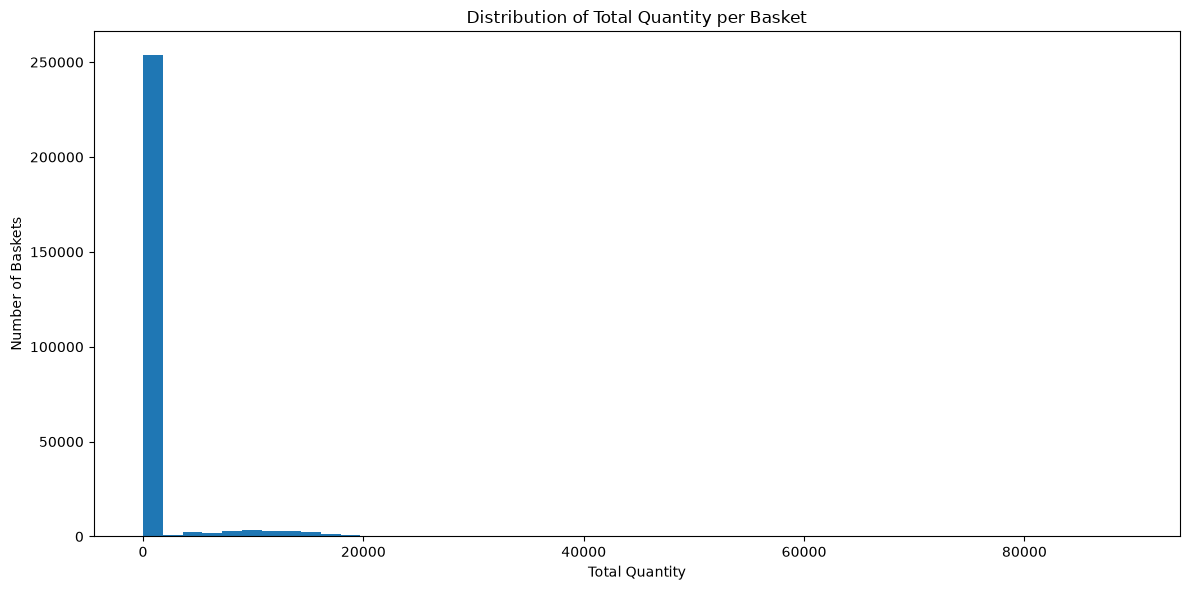

In [69]:
plt.figure(figsize=(12, 6))

plt.hist(
  basket_summary["total_quantity"],
  bins=50
)

plt.xlabel("Total Quantity")
plt.ylabel("Number of Baskets")
plt.title("Distribution of Total Quantity per Basket")

plt.tight_layout()
plt.show()

## 25. Basket Size vs. Basket Value

We will examine the relationship between the number of product lines
and the total value of a basket.

This can help us understand whether larger baskets tend to have
higher monetary value.

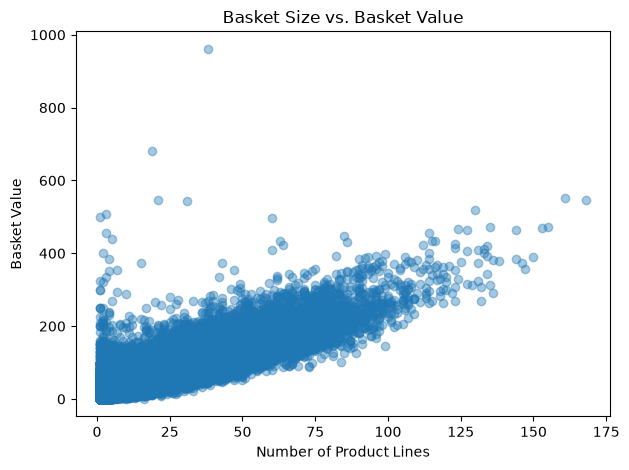

In [73]:
plt.Figure(figsize=(10, 6))

plt.scatter(
  basket_summary["product_lines"],
  basket_summary["basket_value"],
  alpha=0.4
)

plt.xlabel("Number of Product Lines")
plt.ylabel("Basket Value")
plt.title("Basket Size vs. Basket Value")

plt.tight_layout()
plt.show()

## 26. Basket Size and Basket Value Correlation

We will calculate the correlation between product-line count
and basket value.

This provides a numerical measure of the linear relationship
observed in the scatter plot.

In [72]:
basket_correlation = basket_summary[
  ["product_lines", "basket_value"]
].corr()

display(basket_correlation)

,product_lines,basket_value
product_lines,1.00,0.89
basket_value,0.89,1.00


## 28. Product Analysis

The transaction dataset contains product identifiers, but it does not
contain descriptive product information such as department, brand,
manufacturer, or commodity category.

The product dataset provides this additional information.

We will combine the transaction and product datasets to analyze:

- Sales by department
- Sales by commodity
- Product performance
- Quantity sold
- Brand and manufacturer activity

## 29. Product Dataset

We will load the product dataset and inspect its structure before
joining it with the transaction data.

The `PRODUCT_ID` column will be used as the key between the datasets.

In [81]:
products = datasets["product"]

print(f"Product rows: {len(products):,}")
print(f"Product columns: {products.shape[1]}")

Product rows: 92,353
Product columns: 7


In [82]:
product_key_summary = pd.DataFrame({
  "Metric": [
    "Unique transaction PRODUCT_IDs",
    "Unique product PRODUCT_IDs"
  ],
  "Value": [
    transactions["PRODUCT_ID"].nunique(),
    products["PRODUCT_ID"].nunique()
  ]
})

display(product_key_summary)

,Metric,Value
0,Unique transaction PRODUCT_IDs,92339
1,Unique product PRODUCT_IDs,92353


## 31. Merge Transactions with Product Information

We will enrich the transaction data with product attributes.

A left join is used because every transaction should remain in the
analytical dataset, even if product information is unavailable.

In [84]:
transactions_products = transactions.merge(
  products,
  on="PRODUCT_ID",
  how="left"
)

print(f"Original transactions rows: {len(transactions):,}")

print(f"Rows after merge: {len(transactions_products):,}")

Original transactions rows: 2,595,732
Rows after merge: 2,595,732


In [87]:
product_columns = [
  "MANUFACTURER",
  "DEPARTMENT",
  "BRAND",
  "COMMODITY_DESC",
  "SUB_COMMODITY_DESC"
]

product_merge_check = (
  transactions_products[product_columns]
  .isna()
  .sum()
  .to_frame("missing_values")
)

display(product_merge_check)

,missing_values
MANUFACTURER,0
DEPARTMENT,0
BRAND,0
COMMODITY_DESC,0
SUB_COMMODITY_DESC,0


## 31. Merge Transactions with Product Information

We will enrich the transaction data with product attributes.

A left join is used because every transaction should remain in the
analytical dataset, even if product information is unavailable.

In [88]:
departments_sales = (
  transactions_products
  .groupby("DEPARTMENT", as_index=False)["SALES_VALUE"]
  .sum()
  .sort_values(
    "SALES_VALUE",
    ascending=False
  )
)

display(departments_sales)

,DEPARTMENT,SALES_VALUE
17,GROCERY,"4,093,814.14"
10,DRUG GM,"1,055,358.03"
33,PRODUCE,"557,452.11"
21,MEAT,"548,786.81"
20,KIOSK-GAS,"544,222.28"
22,MEAT-PCKGD,"412,436.77"
8,DELI,"260,866.51"
27,PASTRY,"121,739.86"
24,MISC SALES TRAN,"119,960.04"
26,NUTRITION,"97,669.04"


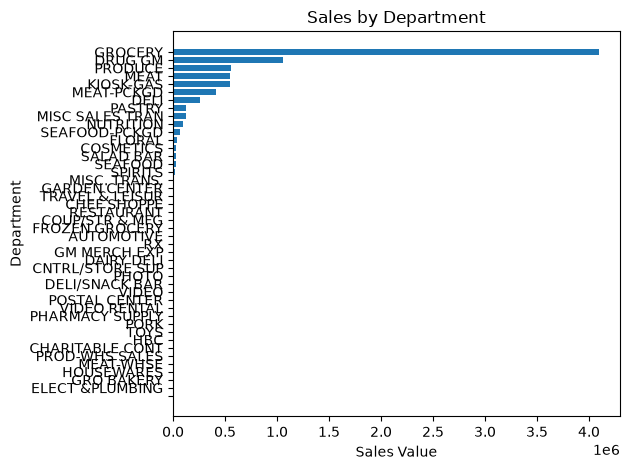

In [90]:
plt.Figure(figsize=(12, 7))

plt.barh(
  departments_sales["DEPARTMENT"],
  departments_sales["SALES_VALUE"]
)

plt.xlabel("Sales Value")
plt.ylabel("Department")
plt.title("Sales by Department")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 35. Top Products by Sales

Department-level analysis provides a broad business view.

We will now identify individual products with the highest total sales
value.

This helps us understand whether sales are concentrated among a small
number of products or distributed across many products.

In [95]:
product_sales = (
  transactions_products
  .groupby(["PRODUCT_ID", "COMMODITY_DESC"], as_index=False)["SALES_VALUE"]
  .sum()
  .sort_values("SALES_VALUE", ascending=False)
)

top_products = product_sales.head(20)
display(top_products)

,PRODUCT_ID,COMMODITY_DESC,SALES_VALUE
57213,6534178,COUPON/MISC ITEMS,"503,867.11"
57173,6533889,COUPON/MISC ITEMS,"46,311.32"
29651,1029743,FLUID MILK PRODUCTS,"41,072.06"
57208,6534166,COUPON/MISC ITEMS,"33,594.48"
35570,1082185,TROPICAL FRUIT,"29,482.00"
16858,916122,CHICKEN,"28,951.93"
57163,6533765,FUEL,"28,837.27"
38256,1106523,FLUID MILK PRODUCTS,"27,818.44"
25748,995242,FLUID MILK PRODUCTS,"26,502.46"
53089,5569230,SOFT DRINKS,"23,651.56"


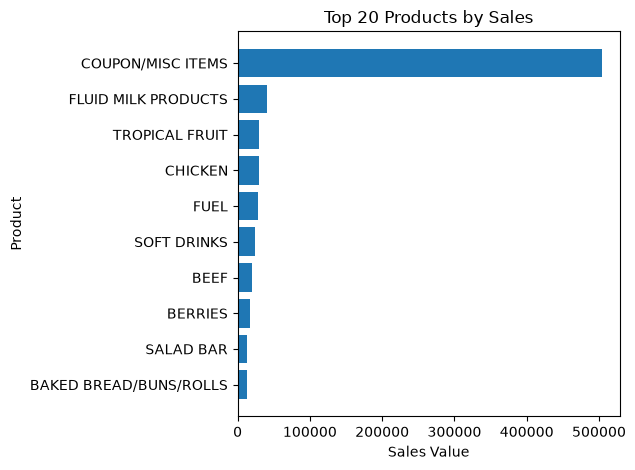

In [96]:
plt.Figure(figsize=(12,8))

plt.barh(
  top_products["COMMODITY_DESC"].astype(str),
  top_products["SALES_VALUE"]
)

plt.xlabel("Sales Value")
plt.ylabel("Product")
plt.title("Top 20 Products by Sales")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 37. Quantity Sold by Department

Sales value and quantity provide different perspectives.

A department may have high sales because of high-priced products,
while another department may sell a very large number of lower-priced items.

We therefore analyze quantity separately from sales value.

In [97]:
department_quantity = (
  transactions_products
  .groupby("DEPARTMENT", as_index=False)["QUANTITY"]
  .sum()
  .sort_values("QUANTITY", ascending=False)
)

display(department_quantity)

,DEPARTMENT,QUANTITY
20,KIOSK-GAS,221254887
24,MISC SALES TRAN,36080860
17,GROCERY,2194762
10,DRUG GM,353844
33,PRODUCE,319993
22,MEAT-PCKGD,148148
21,MEAT,119113
8,DELI,67026
27,PASTRY,49820
26,NUTRITION,43253
